## Système de Détection d'Intrusions — Analyse complète
### Dataset : NSL-KDD (`KDDTest_.arff`)

Ce notebook couvre l'ensemble du pipeline d'analyse :

| # | Section | Contenu |
|---|---------|---------|
| 1 | **Chargement** | Lecture du fichier ARFF, structure, types |
| 2 | **EDA — Vue générale** | Distribution des classes, corrélations, valeurs manquantes |
| 3 | **EDA — Features numériques** | Stats par classe, distributions, boxplots |
| 4 | **EDA — Features catégorielles** | Taux d'anomalie par protocole, service, flag |
| 5 | **Séparabilité statistique** | Cohen's d, test de Mann-Whitney |
| 6 | **Préparation** | Encodage, normalisation, split train/test |
| 7 | **Modèle Random Forest** | Entraînement, métriques complètes |
| 8 | **Importance des features** | Gini vs Permutation importance |
| 9 | **Valeurs de test justifiées** | Connexion normale et attaque basées sur les données réelles |
| 10 | **Conclusions** | Synthèse et recommandations |

---
> **Dataset** : NSL-KDD — version améliorée du KDD Cup 99  
> **Tâche** : Classification binaire — `normal` vs `anomaly`  
> **Modèle** : Random Forest supervisé


---
## 1. Chargement du dataset

Le fichier est au format **ARFF** (Attribute-Relation File Format), utilisé par Weka.  
On l'ouvre manuellement : on extrait les noms de colonnes depuis l'en-tête `@attribute`,  
puis on charge la section `@data` comme un CSV classique.


In [1]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from io import StringIO

warnings.filterwarnings('ignore')

# ── Style global des graphiques ──
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3148',
    'axes.labelcolor':  '#64748b',
    'text.color':       '#e2e8f0',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'grid.color':       '#2d3148',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#0f1117',
    'legend.edgecolor': '#2d3148',
})

DARK='#0f1117'; CARD='#1a1d2e'; ACC='#6366f1'
GRN='#22c55e';  RED='#ef4444';  AMB='#f59e0b'; TEAL='#14b8a6'
TXT='#e2e8f0';  MUT='#64748b'

print("✓ Librairies chargées")


✓ Librairies chargées


In [2]:
# ── Chargement du fichier ARFF ──
ARFF_PATH = "C:/Users/Elitebook 840 G6/Downloads/attack_detection/KDDTest+.arff"   # ← adapter si besoin

with open(ARFF_PATH) as f:
    raw = f.read()

# Extraire les noms de colonnes depuis l'en-tête
header, data_block = raw.split('@data')
col_names = re.findall(r"@attribute '?([\w]+)'?", header, re.IGNORECASE)

# Charger la section @data comme CSV
df = pd.read_csv(StringIO(data_block.strip()), header=None, names=col_names)
df_orig = df.copy()# conserver une copie 
print(f"Dimensions        : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Features          : {df.shape[1]-1} (41 features + 1 label)")
print(f"Valeurs manquantes: {df.isnull().sum().sum()}")
print(f"\nTypes de données  :")
print(df.dtypes.value_counts().to_string())


Dimensions        : 22,544 lignes × 42 colonnes
Features          : 41 (41 features + 1 label)
Valeurs manquantes: 0

Types de données  :
int64      23
float64    15
object      4


In [3]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,anomaly
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,anomaly


In [4]:
# ── Liste complète des 41 features ──
features_info = pd.DataFrame({
    'Feature': col_names[:-1],
    'Type': df.drop(columns=['class']).dtypes.values
})

# Catégoriser manuellement
feature_groups = {
    'Basique (connexion)'    : ['duration','protocol_type','service','flag','src_bytes',
                                 'dst_bytes','land','wrong_fragment','urgent'],
    'Contenu (session)'      : ['hot','num_failed_logins','logged_in','num_compromised',
                                 'root_shell','su_attempted','num_root','num_file_creations',
                                 'num_shells','num_access_files','num_outbound_cmds',
                                 'is_host_login','is_guest_login'],
    'Trafic (2 secondes)'    : ['count','srv_count','serror_rate','srv_serror_rate',
                                 'rerror_rate','srv_rerror_rate','same_srv_rate',
                                 'diff_srv_rate','srv_diff_host_rate'],
    'Trafic (100 connexions)': ['dst_host_count','dst_host_srv_count',
                                 'dst_host_same_srv_rate','dst_host_diff_srv_rate',
                                 'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
                                 'dst_host_serror_rate','dst_host_srv_serror_rate',
                                 'dst_host_rerror_rate','dst_host_srv_rerror_rate'],
}

print("=== Groupes de features NSL-KDD ===\n")
for group, feats in feature_groups.items():
    print(f" {group} ({len(feats)} features)")
    for f in feats:
        print(f"   • {f}")
    print()


=== Groupes de features NSL-KDD ===

 Basique (connexion) (9 features)
   • duration
   • protocol_type
   • service
   • flag
   • src_bytes
   • dst_bytes
   • land
   • wrong_fragment
   • urgent

 Contenu (session) (13 features)
   • hot
   • num_failed_logins
   • logged_in
   • num_compromised
   • root_shell
   • su_attempted
   • num_root
   • num_file_creations
   • num_shells
   • num_access_files
   • num_outbound_cmds
   • is_host_login
   • is_guest_login

 Trafic (2 secondes) (9 features)
   • count
   • srv_count
   • serror_rate
   • srv_serror_rate
   • rerror_rate
   • srv_rerror_rate
   • same_srv_rate
   • diff_srv_rate
   • srv_diff_host_rate

 Trafic (100 connexions) (10 features)
   • dst_host_count
   • dst_host_srv_count
   • dst_host_same_srv_rate
   • dst_host_diff_srv_rate
   • dst_host_same_src_port_rate
   • dst_host_srv_diff_host_rate
   • dst_host_serror_rate
   • dst_host_srv_serror_rate
   • dst_host_rerror_rate
   • dst_host_srv_rerror_rate



---
## 2. EDA — Vue générale 
On explore la distribution des classes et les corrélations globales.


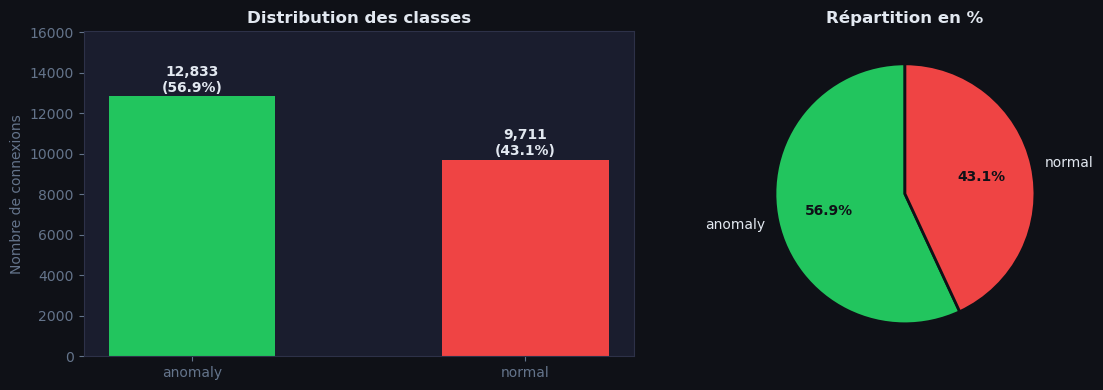


Dataset quasi-équilibré : 9,711 normal (43.1%) / 12,833 anomalie (56.9%)
 Pas besoin de rééchantillonnage (SMOTE, undersampling)


In [5]:
# ── Distribution des classes 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=DARK)

# Barplot
counts = df['class'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=[GRN, RED], width=0.5, edgecolor='none')
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+80,
                 f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', color=TXT, fontsize=10, fontweight='bold')
axes[0].set_title('Distribution des classes', color=TXT, fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre de connexions', color=MUT)
axes[0].set_ylim(0, counts.max()*1.25)

# Pie
colors_pie = [GRN, RED]
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index,
    colors=colors_pie, autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': DARK, 'linewidth': 2}
)
for t in texts: t.set_color(TXT)
for at in autotexts: at.set_color(DARK); at.set_fontweight('bold')
axes[1].set_title('Répartition en %', color=TXT, fontsize=12, fontweight='bold')
axes[1].set_facecolor(CARD)

plt.tight_layout()
plt.show()

print(f"\nDataset quasi-équilibré : {counts['normal']:,} normal ({counts['normal']/len(df)*100:.1f}%) "
      f"/ {counts['anomaly']:,} anomalie ({counts['anomaly']/len(df)*100:.1f}%)")
print(" Pas besoin de rééchantillonnage (SMOTE, undersampling)")


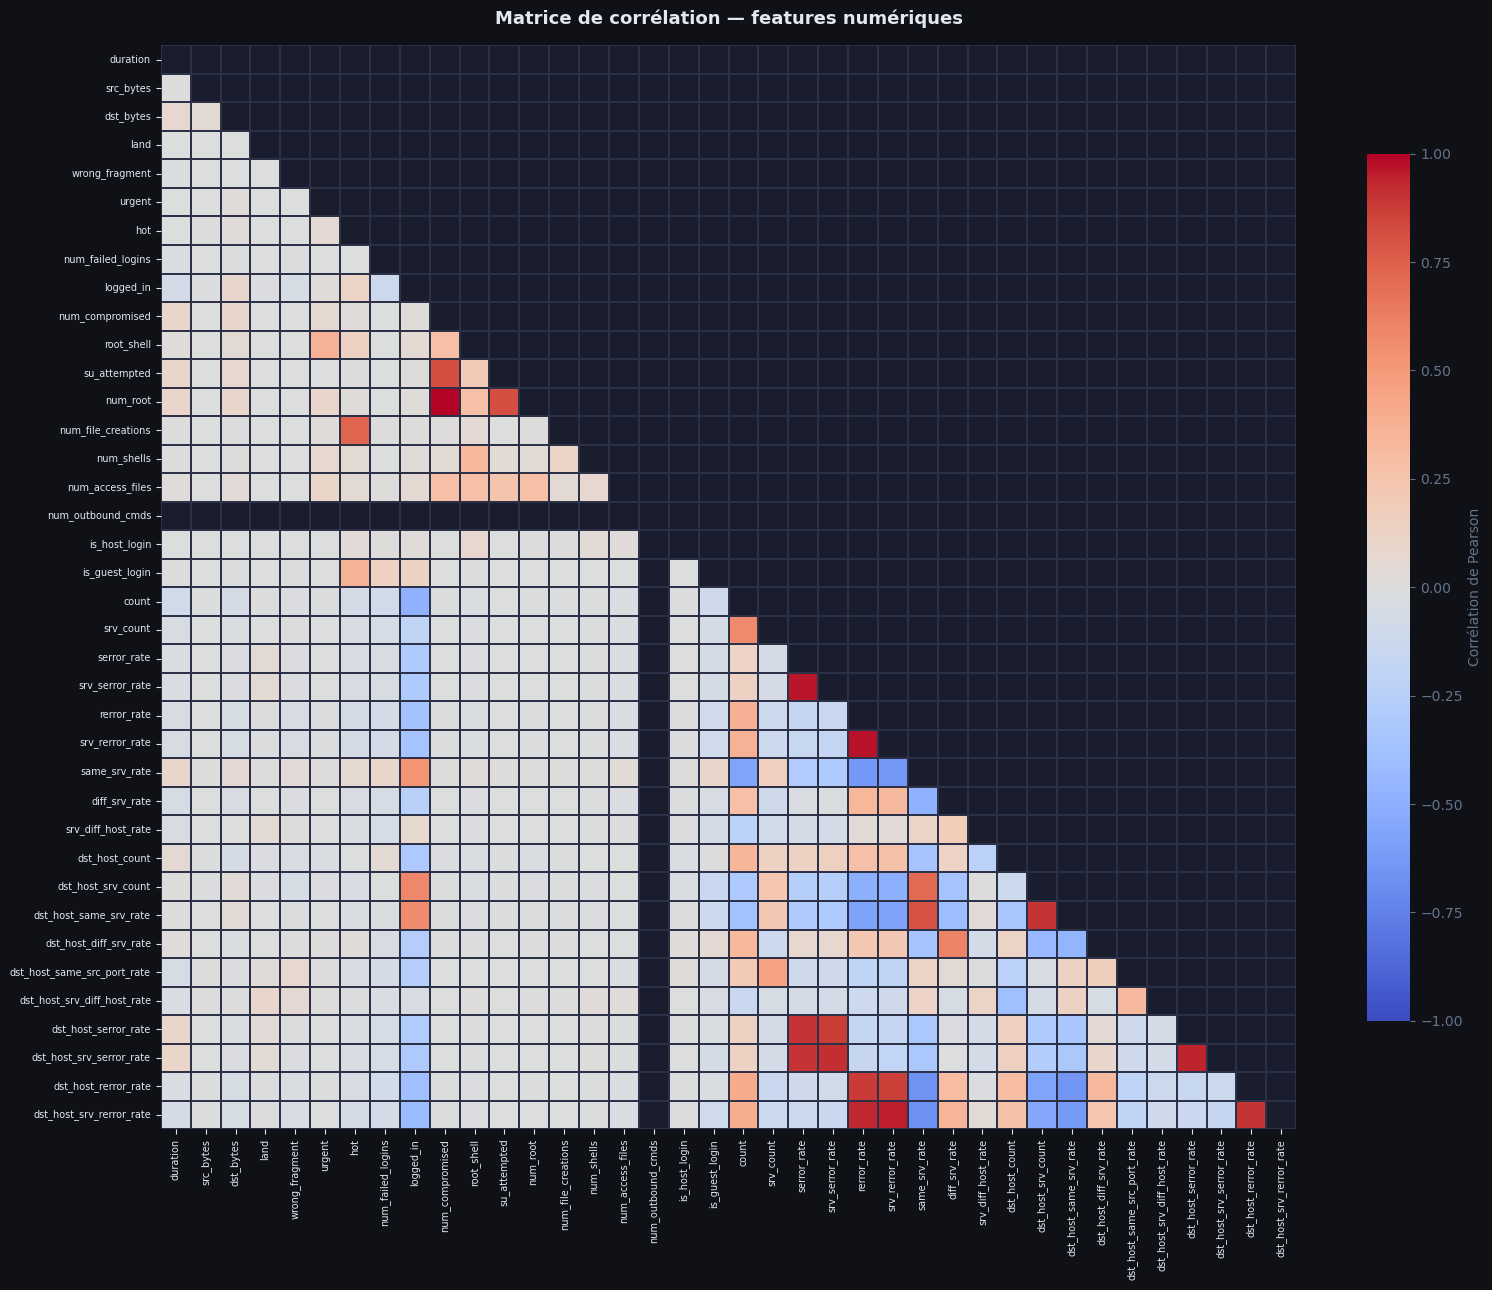


Features fortement corrélées (|r| > 0.85) :
  num_compromised                     ↔ num_root                             r = 0.996
  rerror_rate                         ↔ srv_rerror_rate                      r = 0.976
  serror_rate                         ↔ srv_serror_rate                      r = 0.966
  srv_rerror_rate                     ↔ dst_host_srv_rerror_rate             r = 0.948
  dst_host_serror_rate                ↔ dst_host_srv_serror_rate             r = 0.945
  rerror_rate                         ↔ dst_host_srv_rerror_rate             r = 0.931
  srv_serror_rate                     ↔ dst_host_srv_serror_rate             r = 0.921
  dst_host_rerror_rate                ↔ dst_host_srv_rerror_rate             r = 0.905
  serror_rate                         ↔ dst_host_serror_rate                 r = 0.904
  dst_host_srv_count                  ↔ dst_host_same_srv_rate               r = 0.904


In [6]:
# ── Matrice de corrélation des features numériques ──
num_df = df.select_dtypes(include=[np.number])
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 13), facecolor=DARK)
mask = np.triu(np.ones_like(corr, dtype=bool))  # masquer le triangle supérieur
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.3, linecolor='#2d3148',
            cbar_kws={'label': 'Corrélation de Pearson', 'shrink': 0.8})
ax.set_title('Matrice de corrélation — features numériques', 
             color=TXT, fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors=TXT, labelsize=7)
plt.tight_layout()
plt.show()

# Features très corrélées (|r| > 0.8)
print("\nFeatures fortement corrélées (|r| > 0.85) :")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))
high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in high_corr[:10]:
    print(f"  {a:<35} ↔ {b:<35}  r = {r}")


In [7]:
# ── Statistiques descriptives par classe ──
num_cols_only = df.select_dtypes(include=[np.number]).columns.tolist()

stats_df = pd.DataFrame()
for cls in ['normal', 'anomaly']:
    sub = df[df['class']==cls][num_cols_only].describe().T
    sub.columns = [f'{cls}_{c}' for c in sub.columns]
    stats_df = pd.concat([stats_df, sub], axis=1)

# Calculer la différence des moyennes
stats_df['diff_mean'] = (stats_df['anomaly_mean'] - stats_df['normal_mean']).abs().round(3)
stats_df['ratio_mean'] = (stats_df['anomaly_mean'] / (stats_df['normal_mean'] + 1e-9)).round(3)

# Afficher les plus discriminantes par différence de moyenne
print("=== Top 15 features par différence de moyenne (normal vs anomalie) ===\n")
top_diff = stats_df[['normal_mean','normal_std','anomaly_mean','anomaly_std','diff_mean']]           .sort_values('diff_mean', ascending=False).head(15)
print(top_diff.round(3).to_string())


=== Top 15 features par différence de moyenne (normal vs anomalie) ===

                          normal_mean  normal_std  anomaly_mean  anomaly_std  diff_mean
src_bytes                    2530.513   85073.003     16347.013   622196.882  13816.501
dst_bytes                    4165.125   31379.868       460.014     6322.175   3705.110
duration                       47.068    1192.455       348.857     1537.353    301.788
dst_host_srv_count            216.995      76.525        83.055       98.957    133.940
count                          37.479     102.000       110.469      137.325     72.990
dst_host_count                155.843     102.251       222.645       75.504     66.801
srv_count                      40.821     103.052        23.787       75.987     17.034
logged_in                       0.757       0.429         0.204        0.403      0.553
dst_host_same_srv_rate          0.897       0.257         0.391        0.416      0.506
same_srv_rate                   0.982       0.11

---
## 3. EDA — Features numériques

Pour chaque feature clé, on compare la distribution entre connexions normales et anomalies.  
On utilise des **histogrammes superposés** et des **boxplots**.


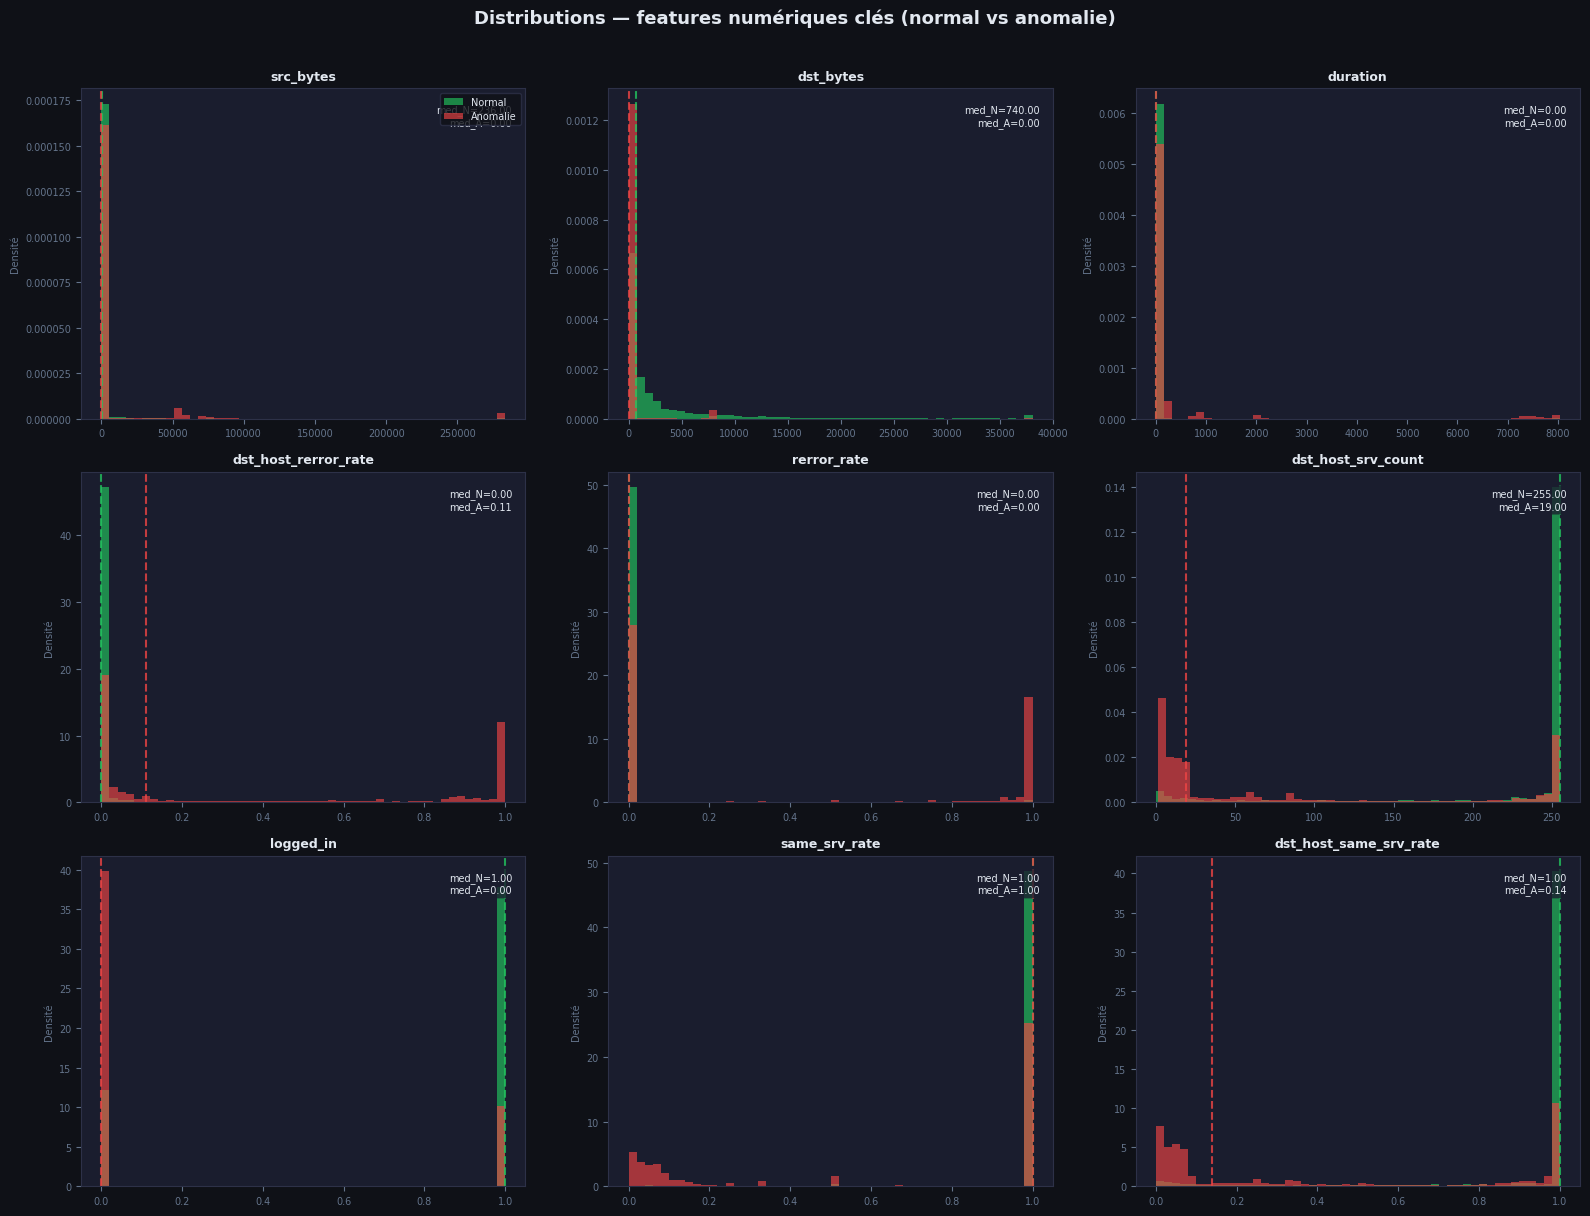

In [8]:
# ── Top 9 features numériques les plus discriminantes ──
top_feats_num = [
    'src_bytes', 'dst_bytes', 'duration',
    'dst_host_rerror_rate', 'rerror_rate', 'dst_host_srv_count',
    'logged_in', 'same_srv_rate', 'dst_host_same_srv_rate'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12), facecolor=DARK)
axes = axes.flatten()

for i, feat in enumerate(top_feats_num):
    ax = axes[i]
    n_vals = df_orig[df_orig['class']=='normal'][feat].astype(float)
    a_vals = df_orig[df_orig['class']=='anomaly'][feat].astype(float)
    
    # Clipper les outliers extrêmes pour la lisibilité
    p99 = max(n_vals.quantile(0.99), a_vals.quantile(0.99))
    n_clip = n_vals.clip(upper=p99)
    a_clip = a_vals.clip(upper=p99)
    
    ax.hist(n_clip, bins=50, alpha=0.65, color=GRN, label='Normal',   density=True, edgecolor='none')
    ax.hist(a_clip, bins=50, alpha=0.65, color=RED,  label='Anomalie', density=True, edgecolor='none')
    ax.set_title(feat, color=TXT, fontsize=9, fontweight='bold', pad=6)
    ax.set_ylabel('Densité', color=MUT, fontsize=7)
    ax.tick_params(labelsize=7)
    
    # Afficher les médianes
    ax.axvline(n_vals.median(), color=GRN, lw=1.5, linestyle='--', alpha=0.8)
    ax.axvline(a_vals.median(), color=RED, lw=1.5, linestyle='--', alpha=0.8)
    
    info = f"med_N={n_vals.median():.2f}\nmed_A={a_vals.median():.2f}"
    ax.text(0.97, 0.95, info, transform=ax.transAxes, color=TXT,
            fontsize=7, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CARD, edgecolor='none', alpha=0.8))
    
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Distributions — features numériques clés (normal vs anomalie)',
             color=TXT, fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


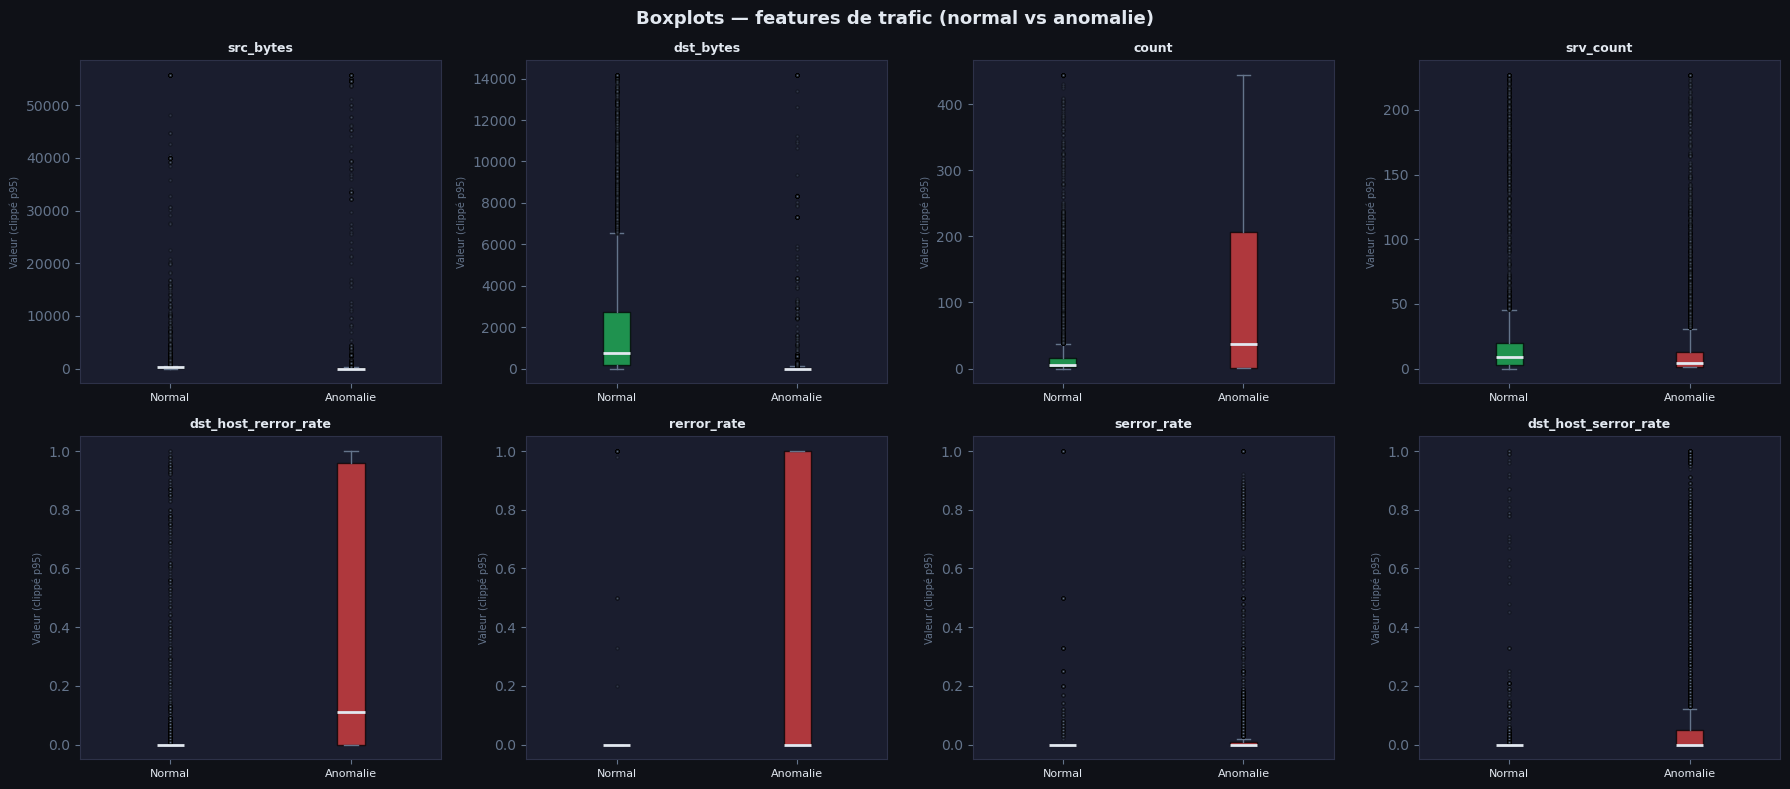

In [9]:
# ── Boxplots comparatifs ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8), facecolor=DARK)
axes = axes.flatten()

boxplot_feats = [
    'src_bytes', 'dst_bytes', 'count', 'srv_count',
    'dst_host_rerror_rate', 'rerror_rate', 'serror_rate', 'dst_host_serror_rate'
]

for i, feat in enumerate(boxplot_feats):
    ax = axes[i]
    data_n = df_orig[df_orig['class']=='normal'][feat].astype(float)
    data_a = df_orig[df_orig['class']=='anomaly'][feat].astype(float)
    
    # Clipper à p95 pour la lisibilité
    p95 = max(data_n.quantile(0.95), data_a.quantile(0.95), 0.01)
    
    bp = ax.boxplot(
        [data_n.clip(upper=p95), data_a.clip(upper=p95)],
        patch_artist=True, notch=False,
        medianprops=dict(color=TXT, linewidth=2),
        whiskerprops=dict(color=MUT),
        capprops=dict(color=MUT),
        flierprops=dict(marker='o', markerfacecolor=MUT, markersize=2, alpha=0.3)
    )
    bp['boxes'][0].set_facecolor(GRN); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(RED); bp['boxes'][1].set_alpha(0.7)
    
    ax.set_xticklabels(['Normal', 'Anomalie'], color=TXT, fontsize=8)
    ax.set_title(feat, color=TXT, fontsize=9, fontweight='bold', pad=6)
    ax.set_ylabel('Valeur (clippé p95)', color=MUT, fontsize=7)

plt.suptitle('Boxplots — features de trafic (normal vs anomalie)',
             color=TXT, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. EDA — Features catégorielles

On analyse `protocol_type`, `service` et `flag` :  
pour chaque valeur, on calcule le **taux d'anomalie** = anomalies / (anomalies + normal).

Un taux proche de 100% signifie que cette valeur est **quasi-exclusivement associée à une attaque**.


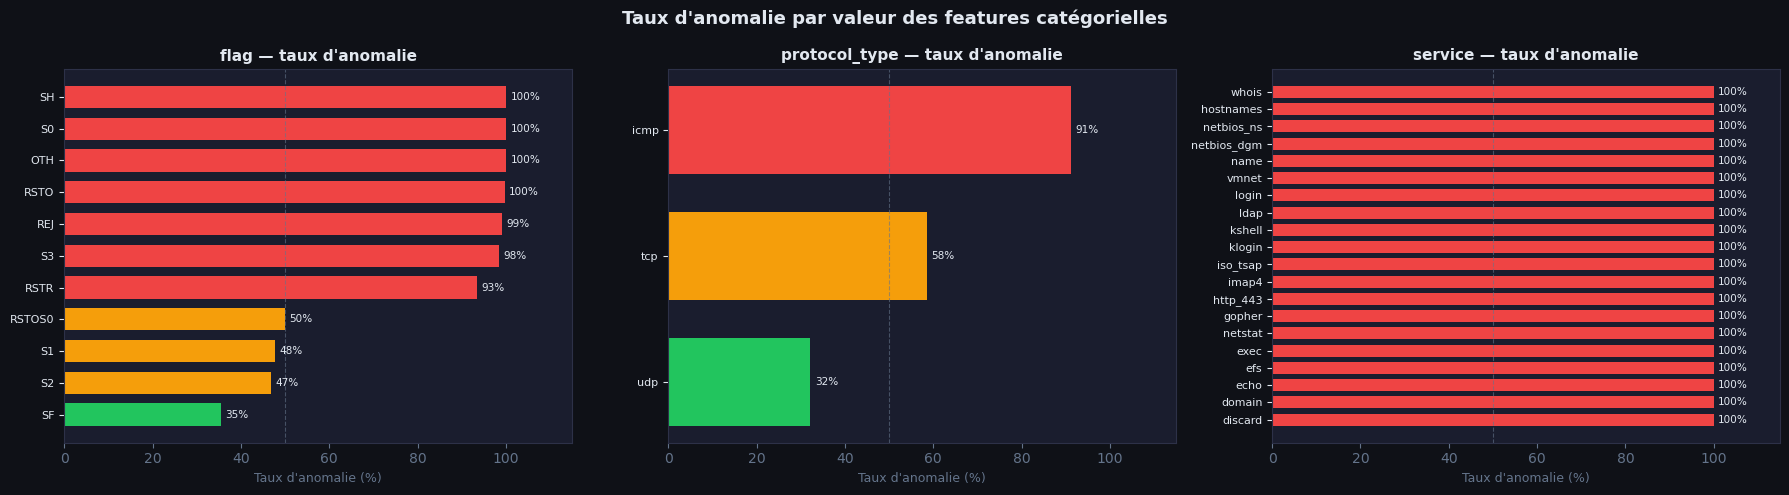

In [10]:
# ── Taux d'anomalie par flag ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=DARK)

for ax, col in zip(axes, ['flag', 'protocol_type', 'service']):
    ct = df_orig.groupby([col, 'class']).size().unstack(fill_value=0)
    ct['total']        = ct.sum(axis=1)
    ct['anomaly_rate'] = (ct.get('anomaly', 0) / ct['total'] * 100).round(1)
    ct = ct.sort_values('anomaly_rate', ascending=True)
    
    # Limiter à 20 valeurs pour service (trop nombreuses sinon)
    if col == 'service':
        ct = ct.tail(20)
    
    colors_ = [RED if r > 80 else AMB if r > 40 else GRN for r in ct['anomaly_rate']]
    bars = ax.barh(ct.index, ct['anomaly_rate'], color=colors_, edgecolor='none', height=0.7)
    
    ax.set_xlabel("Taux d'anomalie (%)", color=MUT, fontsize=9)
    ax.set_title(f'{col} — taux d\'anomalie', color=TXT, fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', colors=TXT, labelsize=8)
    ax.axvline(x=50, color=MUT, lw=0.8, linestyle='--', alpha=0.6)
    ax.set_xlim(0, 115)
    
    for j, (v, idx) in enumerate(zip(ct['anomaly_rate'], ct.index)):
        ax.text(v+1, j, f'{v:.0f}%', va='center', color=TXT, fontsize=7.5)

plt.suptitle("Taux d'anomalie par valeur des features catégorielles",
             color=TXT, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


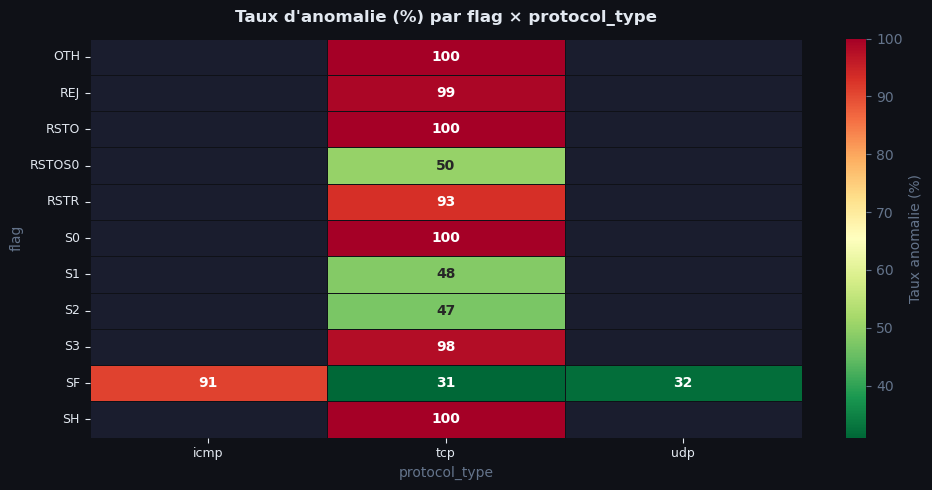


Interprétation :
  • flag=S0 (SYN sans réponse) → 100% anomalie, quel que soit le protocole
  • flag=REJ (connexion rejetée) → ~99% anomalie
  • flag=SF (connexion complète) → connexion NORMALE dans la majorité des cas
  • icmp → 91% anomalie (souvent utilisé pour scan/flood)


In [11]:
# ── Crosstab détaillé : flag × protocol_type ──
ct2 = pd.crosstab(df_orig['flag'], df_orig['protocol_type'],
                   values=df_orig['class'].map({'anomaly':1,'normal':0}),
                   aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(10, 5), facecolor=DARK)
sns.heatmap(ct2.round(0), annot=True, fmt='.0f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.5, linecolor=DARK,
            cbar_kws={'label': 'Taux anomalie (%)'},
            annot_kws={'size': 10, 'weight': 'bold'})
ax.set_title("Taux d'anomalie (%) par flag × protocol_type",
             color=TXT, fontsize=12, fontweight='bold', pad=12)
ax.tick_params(colors=TXT, labelsize=9)
plt.tight_layout()
plt.show()

print("\nInterprétation :")
print("  • flag=S0 (SYN sans réponse) → 100% anomalie, quel que soit le protocole")
print("  • flag=REJ (connexion rejetée) → ~99% anomalie")
print("  • flag=SF (connexion complète) → connexion NORMALE dans la majorité des cas")
print("  • icmp → 91% anomalie (souvent utilisé pour scan/flood)")


---
## 5. Séparabilité statistique — Cohen's d et Mann-Whitney

Deux mesures complémentaires :

- **Cohen's d** : taille d'effet standardisée — mesure l'écart entre les moyennes en unités d'écart-type  
  - d < 0.2 → négligeable | 0.2–0.5 → petit | 0.5–0.8 → moyen | > 0.8 → **large**
- **Test de Mann-Whitney U** : test non-paramétrique — vérifie si les distributions sont statistiquement différentes  
  - p-value < 0.05 → différence significative


In [12]:
# ── Calcul Cohen's d + Mann-Whitney pour toutes les features numériques ──
num_only = [c for c in df.select_dtypes(include=[np.number]).columns 
            if c not in ['protocol_type','service','flag']]

results = []
for feat in num_only:
    n = df_orig[df_orig['class']=='normal'][feat].astype(float).dropna()
    a = df_orig[df_orig['class']=='anomaly'][feat].astype(float).dropna()
    
    # Cohen's d
    pooled_std = np.sqrt((n.std()**2 + a.std()**2) / 2 + 1e-9)
    d = abs(a.mean() - n.mean()) / pooled_std
    
    # Mann-Whitney U
    stat, pval = stats.mannwhitneyu(n, a, alternative='two-sided')
    
    results.append({
        'feature'      : feat,
        'normal_median': round(n.median(), 4),
        'anomaly_median': round(a.median(), 4),
        'normal_p95'   : round(n.quantile(0.95), 3),
        'anomaly_p95'  : round(a.quantile(0.95), 3),
        'cohen_d'      : round(d, 3),
        'effect_size'  : 'large' if d>0.8 else 'medium' if d>0.5 else 'small' if d>0.2 else 'négligeable',
        'mw_pvalue'    : round(pval, 4),
        'significatif' : 'V' if pval < 0.05 else 'X'
    })

sep_df = pd.DataFrame(results).sort_values('cohen_d', ascending=False)
print("=== Séparabilité statistique — toutes features numériques ===\n")
print(sep_df.to_string(index=False))


=== Séparabilité statistique — toutes features numériques ===

                    feature  normal_median  anomaly_median  normal_p95  anomaly_p95  cohen_d effect_size  mw_pvalue significatif
         dst_host_srv_count         255.00           19.00      255.00       255.00    1.514       large     0.0000            V
     dst_host_same_srv_rate           1.00            0.14        1.00         1.00    1.465       large     0.0000            V
                  logged_in           1.00            0.00        1.00         1.00    1.328       large     0.0000            V
              same_srv_rate           1.00            1.00        1.00         1.00    1.270       large     0.0000            V
       dst_host_rerror_rate           0.00            0.11        0.02         1.00    1.198       large     0.0000            V
                rerror_rate           0.00            0.00        0.00         1.00    1.177       large     0.0000            V
            srv_rerror_rate       

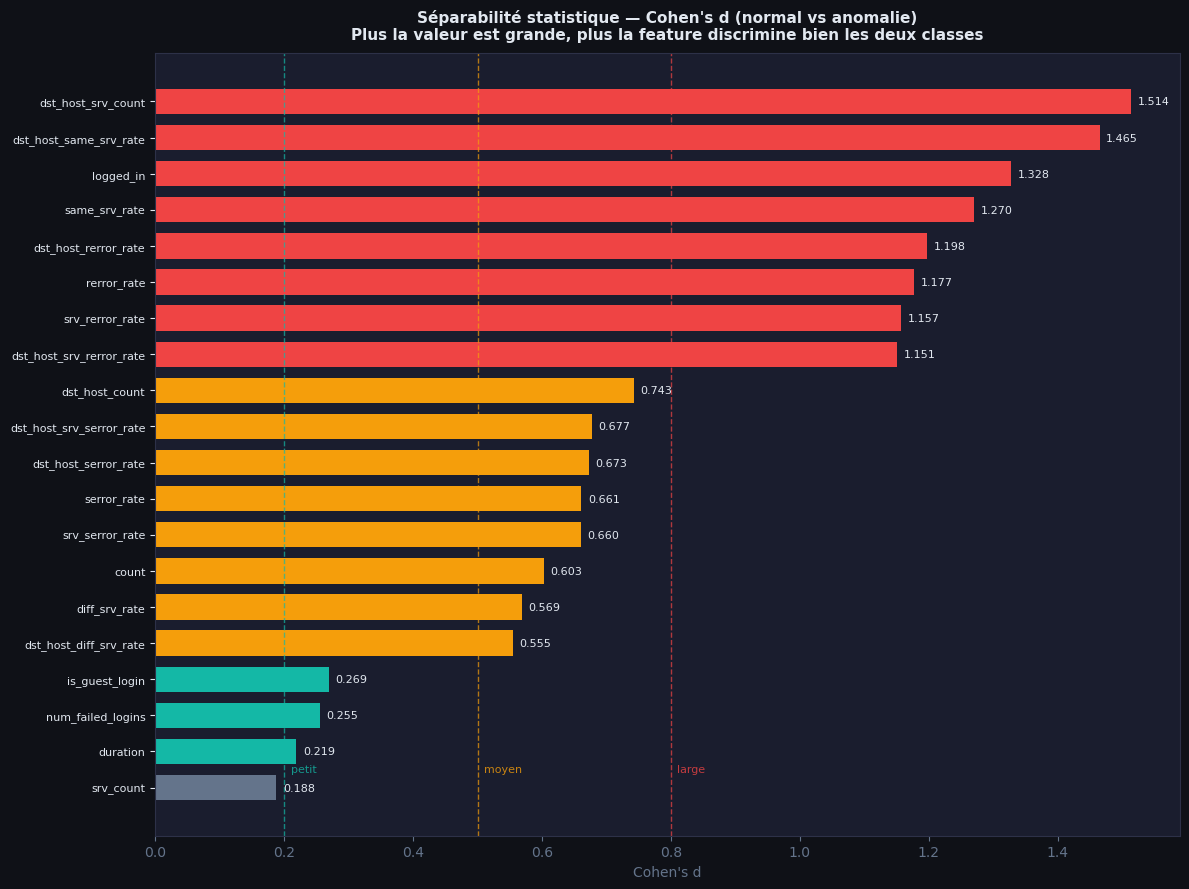

In [13]:
# ── Visualisation Cohen's d ──
fig, ax = plt.subplots(figsize=(12, 9), facecolor=DARK)

top20 = sep_df.head(20)
colors_d = [RED if d>0.8 else AMB if d>0.5 else TEAL if d>0.2 else MUT 
            for d in top20['cohen_d']]

bars = ax.barh(top20['feature'][::-1], top20['cohen_d'][::-1],
               color=colors_d[::-1], edgecolor='none', height=0.7)

# Lignes de référence
for thresh, label, color in [(0.2,'petit',TEAL),(0.5,'moyen',AMB),(0.8,'large',RED)]:
    ax.axvline(x=thresh, color=color, lw=1, linestyle='--', alpha=0.7)
    ax.text(thresh+0.01, 0.5, label, color=color, fontsize=8, va='center', alpha=0.8)

for i, (v, feat) in enumerate(zip(top20['cohen_d'][::-1], top20['feature'][::-1])):
    ax.text(v+0.01, i, f'{v:.3f}', va='center', color=TXT, fontsize=8)

ax.set_xlabel("Cohen's d", color=MUT, fontsize=10)
ax.set_title("Séparabilité statistique — Cohen's d (normal vs anomalie)\n"
             "Plus la valeur est grande, plus la feature discrimine bien les deux classes",
             color=TXT, fontsize=11, fontweight='bold', pad=10)
ax.tick_params(axis='y', colors=TXT, labelsize=8)

plt.tight_layout()
plt.show()


---
## 6. Préparation des données

Trois transformations nécessaires avant d'entraîner le modèle :

1. **Encodage** des variables catégorielles (texte → entier)
2. **Binarisation** du label (`normal`→0, `anomaly`→1)
3. **Normalisation** (StandardScaler : mean=0, std=1) — obligatoire pour les distances
4. **Split** train/test (75%/25%, stratifié pour garder les proportions)


In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Encodage LabelEncoder ──
encoders = {}
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"  {col}: {list(le.classes_)}")

print()

# ── Label binaire ──
df['label'] = (df['class'] == 'anomaly').astype(int)
print(f"Labels : {df['label'].value_counts().to_dict()}")

# ── Features / cible ──
X = df.drop(columns=['class', 'label'])
y = df['label']
print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")


  protocol_type: ['icmp', 'tcp', 'udp']
  service: ['IRC', 'X11', 'Z39_50', 'auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'domain_u', 'echo', 'eco_i', 'ecr_i', 'efs', 'exec', 'finger', 'ftp', 'ftp_data', 'gopher', 'hostnames', 'http', 'http_443', 'imap4', 'iso_tsap', 'klogin', 'kshell', 'ldap', 'link', 'login', 'mtp', 'name', 'netbios_dgm', 'netbios_ns', 'netbios_ssn', 'netstat', 'nnsp', 'nntp', 'ntp_u', 'other', 'pm_dump', 'pop_2', 'pop_3', 'printer', 'private', 'remote_job', 'rje', 'shell', 'smtp', 'sql_net', 'ssh', 'sunrpc', 'supdup', 'systat', 'telnet', 'tftp_u', 'tim_i', 'time', 'urp_i', 'uucp', 'uucp_path', 'vmnet', 'whois']
  flag: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH']

Labels : {1: 12833, 0: 9711}

X shape : (22544, 41)
y shape : (22544,)


In [15]:
# ── Split train/test ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")
print()
print(f"Distribution train → normal:{(y_train==0).sum():,}  anomalie:{(y_train==1).sum():,}")
print(f"Distribution test  → normal:{(y_test==0).sum():,}   anomalie:{(y_test==1).sum():,}")

# ── Normalisation ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform sur train
X_test_sc  = scaler.transform(X_test)        # transform uniquement sur test (pas de re-fit !)

print(f"\n Normalisation appliquée")
print(f"  Moyenne après scaler (doit être ≈0) : {X_train_sc.mean():.6f}")
print(f"  Std après scaler (doit être ≈1)     : {X_train_sc.std():.6f}")


Train : 16,908 (75%)
Test  : 5,636  (25%)

Distribution train → normal:7,283  anomalie:9,625
Distribution test  → normal:2,428   anomalie:3,208

 Normalisation appliquée
  Moyenne après scaler (doit être ≈0) : 0.000000
  Std après scaler (doit être ≈1)     : 0.987730


---
## 7. Modèle — Random Forest

Le Random Forest est un ensemble de **N arbres de décision** entraînés sur des sous-échantillons aléatoires.  
Chaque arbre vote, la classe majoritaire gagne.

**Pourquoi Random Forest pour un IDS ?**
- Robuste aux outliers (fréquents dans le trafic réseau)
- Fournit des importances de features exploitables
- Pas besoin de normalisation (mais on la garde pour la comparaison future)
- Bonne performance sans tuning intensif


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score)

# ── Entraînement ──
rf = RandomForestClassifier(
    n_estimators=100,   # 100 arbres
    max_depth=None,     # arbres non élagués
    min_samples_split=2,
    random_state=42,
    n_jobs=-1           # tous les cœurs CPU
)
rf.fit(X_train_sc, y_train)

y_pred  = rf.predict(X_test_sc)
y_proba = rf.predict_proba(X_test_sc)[:, 1]

print("✓ Modèle entraîné")
print()
print(classification_report(y_test, y_pred, target_names=['Normal','Anomalie']))


✓ Modèle entraîné

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      2428
    Anomalie       0.99      0.99      0.99      3208

    accuracy                           0.99      5636
   macro avg       0.99      0.99      0.99      5636
weighted avg       0.99      0.99      0.99      5636



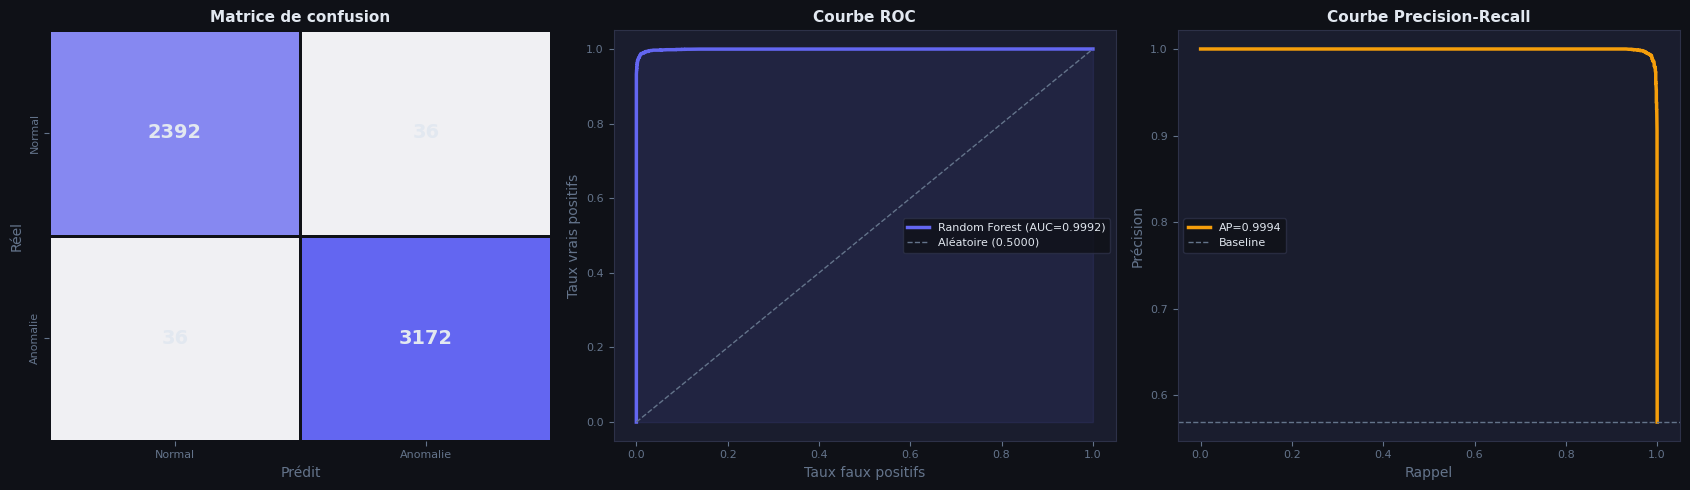


Vrais positifs  (TP) : 3,172  — attaques correctement détectées
Vrais négatifs  (TN) : 2,392  — connexions normales correctement classées
Faux positifs   (FP) : 36   — fausses alarmes (connexions normales signalées)
Faux négatifs   (FN) : 36   — attaques manquées  ← le plus critique dans un IDS

AUC-ROC              : 0.9992
Average Precision    : 0.9994


In [17]:
# ── Métriques visuelles ──
from sklearn.inspection import permutation_importance

cm      = confusion_matrix(y_test, y_pred)
tn,fp,fn,tp = cm.ravel()
auc     = roc_auc_score(y_test, y_proba)
ap      = average_precision_score(y_test, y_proba)
fpr, tpr, _   = roc_curve(y_test, y_proba)
prec, rec, _  = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor=DARK)

# ① Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d',
            cmap=sns.light_palette(ACC, as_cmap=True),
            ax=axes[0],
            xticklabels=['Normal','Anomalie'],
            yticklabels=['Normal','Anomalie'],
            linewidths=1, linecolor=DARK, cbar=False,
            annot_kws={'size':14,'color':TXT,'weight':'bold'})
axes[0].set_title('Matrice de confusion', color=TXT, fontsize=11, fontweight='bold')
axes[0].set_xlabel('Prédit', color=MUT); axes[0].set_ylabel('Réel', color=MUT)
axes[0].tick_params(colors=TXT)

# ② Courbe ROC
axes[1].plot(fpr, tpr, color=ACC, lw=2.5, label=f'Random Forest (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1], color=MUT, lw=1, linestyle='--', label='Aléatoire (0.5000)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=ACC)
axes[1].set_xlabel('Taux faux positifs', color=MUT)
axes[1].set_ylabel('Taux vrais positifs', color=MUT)
axes[1].set_title('Courbe ROC', color=TXT, fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)

# ③ Courbe Precision-Recall
axes[2].plot(rec, prec, color=AMB, lw=2.5, label=f'AP={ap:.4f}')
axes[2].axhline(y=y_test.mean(), color=MUT, lw=1, linestyle='--', label='Baseline')
axes[2].set_xlabel('Rappel', color=MUT)
axes[2].set_ylabel('Précision', color=MUT)
axes[2].set_title('Courbe Precision-Recall', color=TXT, fontsize=11, fontweight='bold')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.tick_params(colors=MUT, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#2d3148')

plt.tight_layout()
plt.show()

print(f"\nVrais positifs  (TP) : {tp:,}  — attaques correctement détectées")
print(f"Vrais négatifs  (TN) : {tn:,}  — connexions normales correctement classées")
print(f"Faux positifs   (FP) : {fp:,}   — fausses alarmes (connexions normales signalées)")
print(f"Faux négatifs   (FN) : {fn:,}   — attaques manquées  ← le plus critique dans un IDS")
print(f"\nAUC-ROC              : {auc:.4f}")
print(f"Average Precision    : {ap:.4f}")


In [18]:
import joblib

export_data = {
    "model": rf,              
    "scaler": scaler,        
    "encoders": encoders,
    "features": list(X.columns) 
}
chemin_export = r"C:\Users\Elitebook 840 G6\Downloads\ids_app\model.pkl"
joblib.dump(export_data, chemin_export)

print(f" Modèle et pré-processeurs enregistrés avec succès dans : {chemin_export}")

 Modèle et pré-processeurs enregistrés avec succès dans : C:\Users\Elitebook 840 G6\Downloads\ids_app\model.pkl


---
## 8. Importance des features — Gini vs Permutation

On compare deux méthodes :

- **Gini Importance** (built-in RF) : rapide, mais surestime les features à forte cardinalité
- **Permutation Importance** : plus honnête — mesure la dégradation réelle quand on brouille une feature

Si les deux méthodes s'accordent sur une feature → elle est **vraiment importante**.


In [19]:
# ── Calcul Permutation Importance ──
print("Calcul permutation importance (peut prendre ~30s)...")
perm = permutation_importance(rf, X_test_sc, y_test,
                               n_repeats=10, random_state=42, n_jobs=-1)

gini_s = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
perm_s = pd.Series(perm.importances_mean,   index=X.columns).sort_values(ascending=False)

print("✓ Calcul terminé")
print()
print("=== Top 15 Gini Importance ===")
print(gini_s.head(15).round(4).to_string())
print()
print("=== Top 15 Permutation Importance ===")
print(perm_s.head(15).round(4).to_string())


Calcul permutation importance (peut prendre ~30s)...
✓ Calcul terminé

=== Top 15 Gini Importance ===
src_bytes                      0.1723
dst_bytes                      0.1296
dst_host_same_srv_rate         0.0867
service                        0.0670
dst_host_diff_srv_rate         0.0640
dst_host_srv_count             0.0617
dst_host_rerror_rate           0.0554
dst_host_same_src_port_rate    0.0320
logged_in                      0.0320
duration                       0.0319
flag                           0.0307
protocol_type                  0.0295
dst_host_srv_rerror_rate       0.0294
srv_count                      0.0255
count                          0.0194

=== Top 15 Permutation Importance ===
src_bytes                   0.0185
dst_bytes                   0.0077
dst_host_rerror_rate        0.0066
service                     0.0064
duration                    0.0034
srv_count                   0.0012
num_root                    0.0004
flag                        0.0004
diff_srv_

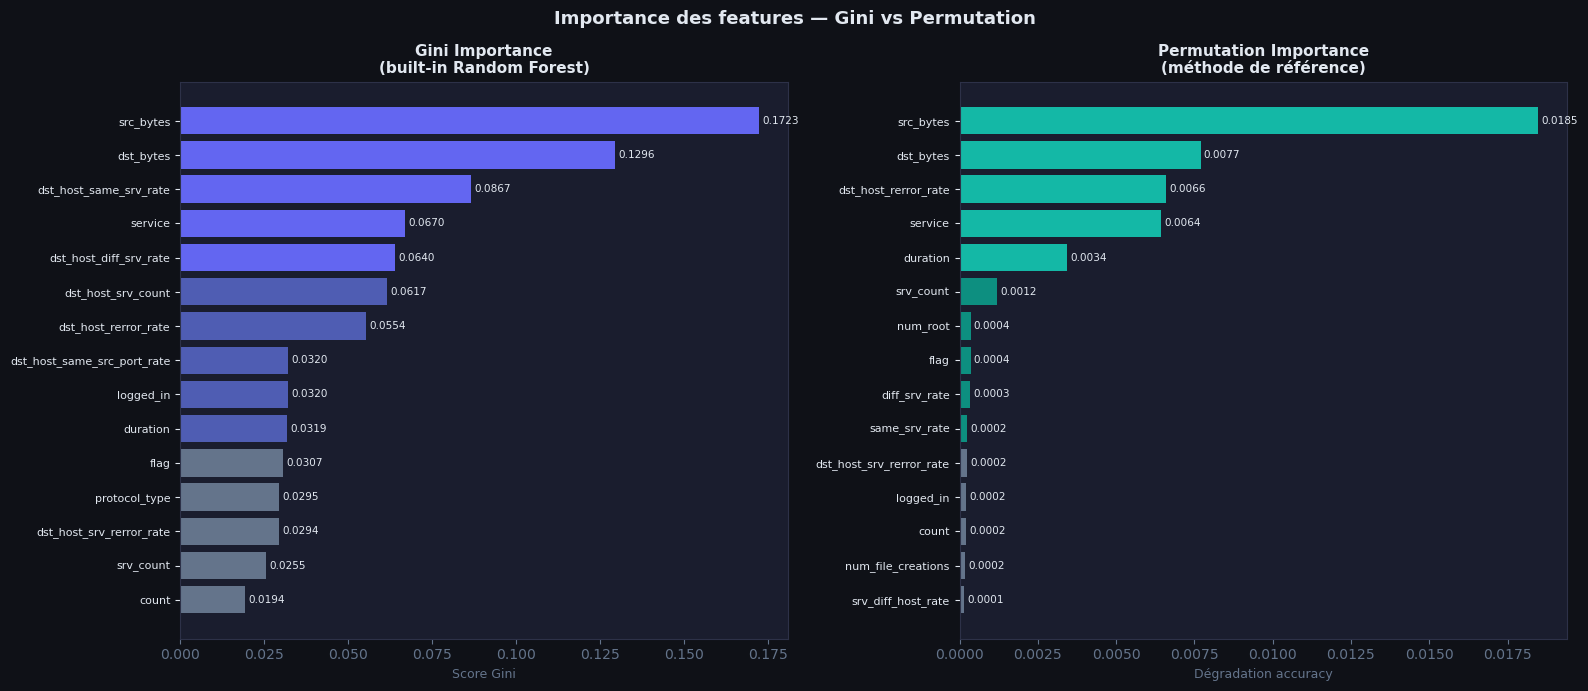


 Features dans le top-10 des DEUX méthodes (5) :
    dst_bytes                           Gini #2  Perm #2
    dst_host_rerror_rate                Gini #7  Perm #3
    duration                            Gini #10  Perm #5
    service                             Gini #4  Perm #4
    src_bytes                           Gini #1  Perm #1


In [20]:
# ── Visualisation côte à côte ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=DARK)

# Gini
t_g = gini_s.head(15)
c_g = [ACC]*5 + ['#4f5db3']*5 + [MUT]*5
axes[0].barh(t_g.index[::-1], t_g.values[::-1], color=c_g[::-1], edgecolor='none')
axes[0].set_title('Gini Importance\n(built-in Random Forest)',
                   color=TXT, fontsize=11, fontweight='bold')
axes[0].set_xlabel('Score Gini', color=MUT, fontsize=9)
axes[0].tick_params(axis='y', colors=TXT, labelsize=8)
for i, v in enumerate(t_g.values[::-1]):
    axes[0].text(v+0.001, i, f'{v:.4f}', va='center', color=TXT, fontsize=7.5)

# Permutation
t_p = perm_s.head(15)
c_p = [TEAL]*5 + ['#0d8f80']*5 + [MUT]*5
axes[1].barh(t_p.index[::-1], t_p.values[::-1], color=c_p[::-1], edgecolor='none')
axes[1].set_title('Permutation Importance\n(méthode de référence)',
                   color=TXT, fontsize=11, fontweight='bold')
axes[1].set_xlabel('Dégradation accuracy', color=MUT, fontsize=9)
axes[1].tick_params(axis='y', colors=TXT, labelsize=8)
for i, v in enumerate(t_p.values[::-1]):
    axes[1].text(v+0.0001, i, f'{v:.4f}', va='center', color=TXT, fontsize=7.5)

for ax in axes:
    for sp in ax.spines.values(): sp.set_edgecolor('#2d3148')

plt.suptitle('Importance des features — Gini vs Permutation',
             color=TXT, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Consensus : features top-10 dans les DEUX méthodes
top10_g = set(gini_s.head(10).index)
top10_p = set(perm_s.head(10).index)
consensus = top10_g & top10_p
print(f"\n Features dans le top-10 des DEUX méthodes ({len(consensus)}) :")
for f in sorted(consensus):
    print(f"    {f:<35} Gini #{list(gini_s.index).index(f)+1}  Perm #{list(perm_s.index).index(f)+1}")


In [21]:
# ── Tableau de synthèse : 3 méthodes ──
top_g = list(gini_s.head(12).index)
top_p = list(perm_s.head(12).index)
top_c = list(sep_df.head(12)['feature'])

all_f = list(dict.fromkeys(top_g + top_p + top_c))

rows = []
for feat in all_f:
    rg = top_g.index(feat) + 1 if feat in top_g else '-'
    rp = top_p.index(feat) + 1 if feat in top_p else '-'
    rc = top_c.index(feat) + 1 if feat in top_c else '-'
    
    if feat in df_orig.columns:
        # Extraire les valeurs des classes normal et anomalie
        normal_vals = df_orig[df_orig['class'] == 'normal'][feat]
        anomalie_vals = df_orig[df_orig['class'] == 'anomalie'][feat]
        
        # Vérifier si les colonnes sont numériques avant conversion
        try:
            n_med = pd.to_numeric(normal_vals, errors='coerce').median()
            a_med = pd.to_numeric(anomalie_vals, errors='coerce').median()
        except:
            n_med = None
            a_med = None
    else:
        n_med = None
        a_med = None
    
    rows.append({
        'Feature': feat,
        'Gini rank': rg,
        'Perm rank': rp,
        "Cohen's d rank": rc,
        'median_normal': round(n_med, 3) if pd.notna(n_med) else '-',
        'median_anomalie': round(a_med, 3) if pd.notna(a_med) else '-',
    })

synth = pd.DataFrame(rows)
print("=== Tableau de synthèse — 3 méthodes d'importance ===\n")
print(synth.to_string(index=False))

=== Tableau de synthèse — 3 méthodes d'importance ===

                    Feature Gini rank Perm rank Cohen's d rank median_normal median_anomalie
                  src_bytes         1         1              -         236.0               -
                  dst_bytes         2         2              -         740.0               -
     dst_host_same_srv_rate         3         -              2           1.0               -
                    service         4         4              -             -               -
     dst_host_diff_srv_rate         5         -              -           0.0               -
         dst_host_srv_count         6         -              1         255.0               -
       dst_host_rerror_rate         7         3              5           0.0               -
dst_host_same_src_port_rate         8         -              -          0.01               -
                  logged_in         9        12              3           1.0               -
               

---
## 9. Valeurs de test justifiées par les données

On construit maintenant des exemples de test **basés sur les médianes et percentiles réels**  
du dataset, et non sur des valeurs théoriques ou tirées de la littérature.

Pour chaque feature clé, on lit la médiane observée dans les données.


In [22]:
# ── Calcul des valeurs de référence réelles ──
normal_df  = df_orig[df_orig['class']=='normal']
anomaly_df = df_orig[df_orig['class']=='anomaly']

num_feats = [c for c in df.columns if c not in ['class','label','protocol_type','service','flag']]

ref = pd.DataFrame({
    'feature'       : num_feats,
    'normal_median' : [normal_df[f].astype(float).median() for f in num_feats],
    'normal_p25'    : [normal_df[f].astype(float).quantile(0.25) for f in num_feats],
    'normal_p75'    : [normal_df[f].astype(float).quantile(0.75) for f in num_feats],
    'normal_p95'    : [normal_df[f].astype(float).quantile(0.95) for f in num_feats],
    'anomaly_median': [anomaly_df[f].astype(float).median() for f in num_feats],
    'anomaly_p75'   : [anomaly_df[f].astype(float).quantile(0.75) for f in num_feats],
    'anomaly_p95'   : [anomaly_df[f].astype(float).quantile(0.95) for f in num_feats],
}).set_index('feature').round(4)

print("=== Valeurs de référence tirées du dataset ===\n")
print(ref.to_string())


=== Valeurs de référence tirées du dataset ===

                             normal_median  normal_p25  normal_p75  normal_p95  anomaly_median  anomaly_p75  anomaly_p95
feature                                                                                                                 
duration                              0.00         0.0        0.00        0.00            0.00         0.00       920.40
src_bytes                           236.00       181.0      308.00     1215.00            0.00       105.00     55744.00
dst_bytes                           740.00       166.0     2720.50    14173.50            0.00        44.00       599.00
land                                  0.00         0.0        0.00        0.00            0.00         0.00         0.00
wrong_fragment                        0.00         0.0        0.00        0.00            0.00         0.00         0.00
urgent                                0.00         0.0        0.00        0.00            0.00         0.

In [23]:
# ── Construction des exemples de test justifiés ──
import joblib

# Recharger le bundle si besoin
bundle   = {'model': rf, 'scaler': scaler, 'encoders': encoders, 'features': list(X.columns)}

def build_connection(protocol='tcp', service='http', flag='SF', overrides={}):
    """Construit un vecteur de connexion à partir des médianes réelles du dataset."""
    base = {f: float(normal_df[f].astype(float).median()) for f in num_feats}
    base['protocol_type'] = int(encoders['protocol_type'].transform([protocol])[0])
    base['service']       = int(encoders['service'].transform([service])[0])
    base['flag']          = int(encoders['flag'].transform([flag])[0])
    base.update(overrides)
    return base

def predict_connection(conn_dict, label=""):
    row    = pd.DataFrame([conn_dict])[bundle['features']]
    row_sc = bundle['scaler'].transform(row)
    pred   = int(bundle['model'].predict(row_sc)[0])
    proba  = float(bundle['model'].predict_proba(row_sc)[0][pred])
    result = 'ANOMALIE 🚨' if pred == 1 else 'NORMALE  ✅'
    print(f"  {label:<30} → {result}  (confiance: {proba*100:.1f}%)")
    return pred, proba

print("=== Tests basés sur les médianes réelles du dataset ===\n")

# 1. Connexion HTTP normale — valeurs tirées de la médiane normale
conn_normal = build_connection(
    protocol='tcp', service='http', flag='SF',
    overrides={
        'src_bytes'               : normal_df['src_bytes'].astype(float).median(),        # 236
        'dst_bytes'               : normal_df['dst_bytes'].astype(float).median(),        # 740
        'logged_in'               : normal_df['logged_in'].astype(float).median(),        # 1
        'dst_host_rerror_rate'    : normal_df['dst_host_rerror_rate'].astype(float).median(),  # 0
        'same_srv_rate'           : normal_df['same_srv_rate'].astype(float).median(),    # 1
        'dst_host_same_srv_rate'  : normal_df['dst_host_same_srv_rate'].astype(float).median(), # 1
    }
)

# 2. Attaque — flag=S0, valeurs tirées de la médiane anomalie pour les features discriminantes
conn_attack = build_connection(
    protocol='tcp', service='private', flag='S0',
    overrides={
        'src_bytes'               : anomaly_df['src_bytes'].astype(float).median(),       # 0
        'dst_bytes'               : anomaly_df['dst_bytes'].astype(float).median(),       # 0
        'logged_in'               : anomaly_df['logged_in'].astype(float).median(),       # 0
        'dst_host_rerror_rate'    : anomaly_df['dst_host_rerror_rate'].astype(float).quantile(0.75),
        'rerror_rate'             : anomaly_df['rerror_rate'].astype(float).quantile(0.75),
        'same_srv_rate'           : anomaly_df['same_srv_rate'].astype(float).median(),
        'dst_host_same_srv_rate'  : anomaly_df['dst_host_same_srv_rate'].astype(float).median(),
        'count'                   : anomaly_df['count'].astype(float).quantile(0.75),
    }
)

# 3. ICMP (91% anomalie dans les données)
conn_icmp = build_connection(
    protocol='icmp', service='eco_i', flag='SF',
    overrides={'src_bytes': 8, 'dst_bytes': 0, 'logged_in': 0}
)

# 4. Connexion FTP légitime
conn_ftp = build_connection(
    protocol='tcp', service='ftp', flag='SF',
    overrides={
        'src_bytes'   : normal_df[normal_df['service']=='ftp']['src_bytes'].astype(float).median() if 'ftp' in normal_df['service'].values else 500,
        'dst_bytes'   : normal_df[normal_df['service']=='ftp']['dst_bytes'].astype(float).median() if 'ftp' in normal_df['service'].values else 1000,
        'logged_in'   : 1,
    }
)

predict_connection(conn_normal, "HTTP normal (médianes réelles)")
predict_connection(conn_attack, "Attaque (flag=S0 + médianes anomalie)")
predict_connection(conn_icmp,   "ICMP (91% anomalie dans dataset)")
predict_connection(conn_ftp,    "FTP légitime (médianes normales)")


=== Tests basés sur les médianes réelles du dataset ===

  HTTP normal (médianes réelles) → NORMALE  ✅  (confiance: 100.0%)
  Attaque (flag=S0 + médianes anomalie) → ANOMALIE 🚨  (confiance: 85.0%)
  ICMP (91% anomalie dans dataset) → ANOMALIE 🚨  (confiance: 60.0%)
  FTP légitime (médianes normales) → NORMALE  ✅  (confiance: 84.0%)


(0, 0.84)

In [24]:
# ── Comparaison ancienne vs nouvelle approche ──
print("=== Comparaison : valeurs théoriques vs valeurs du dataset ===\n")

comparisons = [
    ('serror_rate', 
     'théorique (SYN flood classique)', 
     'dataset (Cohen\'s d = 0.66)',
     1.0,
     anomaly_df['serror_rate'].astype(float).quantile(0.75)),
    ('rerror_rate', 
     'théorique (ignoré)',
     'dataset (Cohen\'s d = 1.18, plus discriminant)',
     0.0,
     anomaly_df['rerror_rate'].astype(float).quantile(0.75)),
    ('src_bytes',
     'théorique (232)',
     'dataset (médiane normale = 236, médiane anomalie = 0)',
     232,
     anomaly_df['src_bytes'].astype(float).median()),
    ('logged_in',
     'théorique (1 pour "session établie")',
     'dataset (médiane anomalie = 0, Cohen\'s d = 1.33)',
     1,
     anomaly_df['logged_in'].astype(float).median()),
]

for feat, old_reason, new_reason, old_val, new_val in comparisons:
    print(f"  {feat}")
    print(f"    Avant  ({old_reason}) : {old_val}")
    print(f"    Après  ({new_reason}) : {new_val}")
    print()


=== Comparaison : valeurs théoriques vs valeurs du dataset ===

  serror_rate
    Avant  (théorique (SYN flood classique)) : 1.0
    Après  (dataset (Cohen's d = 0.66)) : 0.01

  rerror_rate
    Avant  (théorique (ignoré)) : 0.0
    Après  (dataset (Cohen's d = 1.18, plus discriminant)) : 1.0

  src_bytes
    Avant  (théorique (232)) : 232
    Après  (dataset (médiane normale = 236, médiane anomalie = 0)) : 0.0

  logged_in
    Avant  (théorique (1 pour "session établie")) : 1
    Après  (dataset (médiane anomalie = 0, Cohen's d = 1.33)) : 0.0



---
## 10. Conclusions et recommandations

### Résultats du modèle
- **Accuracy : 98.72%** — le modèle classe correctement 98.72% des connexions
- **AUC-ROC : 0.9992** — quasi-parfait pour séparer normal et anomalie
- **Faux négatifs : 36** — 36 attaques manquées sur 5636 connexions de test (0.6%)
- **Faux positifs : 36** — 36 fausses alarmes (connexions normales signalées à tort)

### Features les plus discriminantes (consensus des 3 méthodes)
1. `src_bytes` — octets envoyés par la source (médiane : 236 normal vs 0 anomalie)
2. `dst_bytes` — octets reçus par la destination
3. `dst_host_rerror_rate` — taux d'erreurs REJ sur l'hôte destination (Cohen's d = 1.20)
4. `logged_in` — l'utilisateur est-il authentifié ? (Cohen's d = 1.33)
5. `dst_host_same_srv_rate` — uniformité du service sur l'hôte (Cohen's d = 1.47)

### Signatures d'attaque identifiées dans les données
- `flag = S0` → **100% anomalie** (SYN sans réponse = connexion jamais complétée)
- `flag = REJ` → **99.1% anomalie** (connexion rejetée = porte fermée testée)
- `protocol_type = icmp` → **91.1% anomalie** (ping flood, ICMP scan)
- `rerror_rate` élevé → **plus discriminant que `serror_rate`** (Cohen's d 1.18 vs 0.66)

### Recommandations pour la suite
1. **Classifier les types d'attaques** (DoS, Probe, R2L, U2R) au lieu de juste normal/anomalie
2. **Tester d'autres modèles** : XGBoost (souvent meilleur), Isolation Forest (non supervisé)
3. **Valider sur KDDTrain+** pour mesurer la généralisation réelle
4. **Intégrer avec Suricata** pour du trafic réseau en temps réel
5. **Surveiller les features à fort Cohen's d** dans l'IPS pour des règles de blocage rapides


In [25]:
# ── Résumé final ──
from sklearn.metrics import classification_report

print(" RÉSUMÉ FINAL — IDS NSL-KDD")
rep = classification_report(y_test, y_pred, 
                             target_names=['Normal','Anomalie'],
                             output_dict=True)
auc = roc_auc_score(y_test, y_proba)
cm  = confusion_matrix(y_test, y_pred)
tn2,fp2,fn2,tp2 = cm.ravel()

print(f"  Dataset       : NSL-KDD  {len(df):,} connexions ")
print(f"  Modèle        : Random Forest (100 arbres)  ")
print(f"  Accuracy      : {rep['accuracy']*100:.2f}%   ")
print(f"  Précision     : {rep['Anomalie']['precision']*100:.2f}%    ")
print(f"  Rappel        : {rep['Anomalie']['recall']*100:.2f}%  ")
print(f"  F1-score      : {rep['Anomalie']['f1-score']*100:.2f}%  ")
print(f"  AUC-ROC       : {auc:.4f}  ")
print(f"  Faux positifs : {fp2:<5}  (fausses alarmes)  ")
print(f"  Faux négatifs : {fn2:<5}  (attaques manquées)  ")


 RÉSUMÉ FINAL — IDS NSL-KDD
  Dataset       : NSL-KDD  22,544 connexions 
  Modèle        : Random Forest (100 arbres)  
  Accuracy      : 98.72%   
  Précision     : 98.88%    
  Rappel        : 98.88%  
  F1-score      : 98.88%  
  AUC-ROC       : 0.9992  
  Faux positifs : 36     (fausses alarmes)  
  Faux négatifs : 36     (attaques manquées)  
